<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/Data_Analysis/DA01/%EC%9E%90%EC%A0%84%EA%B1%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
최종 테스트 데이터 MSE: 3837.6526
최종 테스트 데이터 RMSE: 61.9488
최종 테스트 데이터 RMSLE: 0.4380


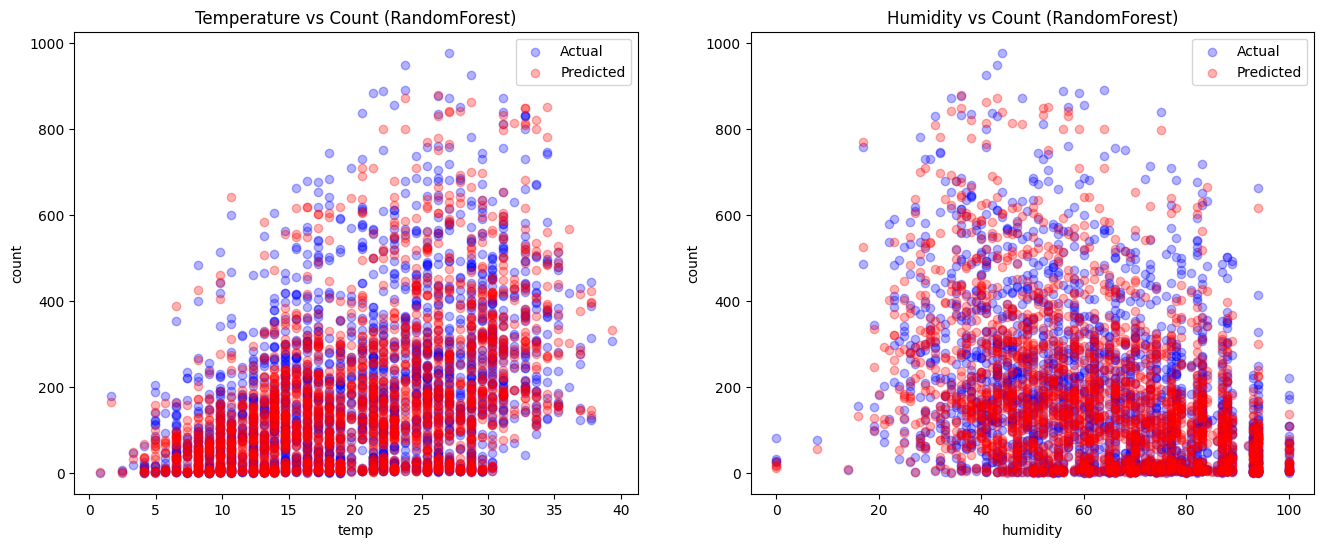

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor # [추가] 더 강력한 모델
from sklearn.metrics import mean_squared_error

# 1. 데이터 로드 (경로 수정 권장: 구글 드라이브 마운트 후)
# from google.colab import drive
# drive.mount('/content/drive')
# train = pd.read_csv("/content/drive/MyDrive/data/bike-sharing-demand/train.csv")

# 임시로 로컬 경로로 설정 (Colab 사용 시 위 코드로 교체)
#train = pd.read_csv("train.csv")
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

train = pd.read_csv("/content/drive/MyDrive/data/bike-sharing-demand/train.csv")

# 2. 데이터 전처리 및 피처 엔지니어링
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
# minute, second는 모두 0이므로 제외

# [추가 전략 2] 범주형 피처 처리 (One-Hot Encoding)
# season, holiday, workingday, weather는 숫자지만 카테고리 정보입니다.
# 선형 모델에서는 이들을 원-핫 인코딩 해주는 것이 성능 향상에 도움이 됩니다.
# 여기서는 시간(hour)도 카테고리로 취급하여 처리해보겠습니다.
train = pd.get_dummies(train, columns=['season', 'weather', 'hour'], drop_first=True)

# [추가 전략 3] 날씨 변수 처리 및 새로운 피처 생성
# windspeed가 0인 데이터가 많습니다. 이는 측정이 안 된 노이즈일 가능성이 높으므로 평균값 등으로 대체하는 것이 좋습니다.
train.loc[train['windspeed'] == 0, 'windspeed'] = train['windspeed'].mean()

# 체감 온도(atemp)와 실제 온도(temp)의 차이 피처 생성
train['temp_diff'] = train['atemp'] - train['temp']

# 3. 데이터 분리
# 사용할 피처 선택 (원-핫 인코딩으로 늘어난 피처들을 포함해야 함)
# 'casual', 'registered', 'datetime', 'atemp', 'day', 'minute', 'second' 제외
# drop_cols = ['count', 'casual', 'registered', 'datetime', 'atemp', 'day', 'minute', 'second']
# X = train.drop(columns=drop_cols)
# y = train['count']

# 또는 필요한 피처만 명시적으로 선택 (원-핫 인코딩 된 피처 이름 확인 필요)
# 이번 예시에서는 drop 방식을 사용하겠습니다.
drop_cols = ['count', 'casual', 'registered', 'datetime', 'atemp', 'day']
X = train.drop(columns=drop_cols)
y = train['count']

# [추가 전략 1] 타겟 변수 로그 변환
# 대여량(count)은 0보다 크고 오른쪽으로 긴 꼬리를 가진 분포를 가집니다.
# 이를 로그 변환하면 정규 분포와 가까워져 모델 학습이 훨씬 잘 됩니다.
# 주의: 로그 변환 시 0값이 있으면 에러가 나므로 log1p (log(1+x))를 사용합니다.
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 4. 모델 학습 및 평가
# [추가 전략 4] 모델 변경: LinearRegression -> RandomForestRegressor
# 선형 회귀 모델의 한계를 극복하기 위해 트리 기반의 랜덤 포레스트 모델을 사용합니다.
# RandomForest는 범주형 변수의 원-핫 인코딩 없이도 잘 작동하지만, 위에서 했으므로 그대로 둡니다.

# model = LinearRegression() # 기존 모델
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # 강력한 모델 사용 -- 이걸 어떻게 알어.
model.fit(X_train, y_train_log)

# 5. 예측 및 평가
y_pred_log = model.predict(X_test)

# 중요: 예측값은 로그 변환된 값이므로, 실제 값으로 되돌려야 합니다. (exp1m 사용)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

# MSE/RMSE 계산 (실제값 기준)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 대형 대회(Kaggle)에서는 RMSLE (Root Mean Squared Logarithmic Error)를 사용합니다.
# 우리가 로그 변환 후 MSE를 구한 것이 결국 RMSLE와 유사한 효과를 냅니다.
rmsle = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

print(f"최종 테스트 데이터 MSE: {mse:.4f}")
print(f"최종 테스트 데이터 RMSE: {rmse:.4f}")
print(f"최종 테스트 데이터 RMSLE: {rmsle:.4f}")

# 6. 결과 시각화 (기존 코드 활용)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
# 원-핫 인코딩을 안 한 원본 temp 데이터를 가져오기 위해 train 데이터를 다시 사용하거나 X_test를 수정해야 함.
# 여기서는 시각화를 위해 X_test의 temp 컬럼을 그대로 사용 (원-핫 인코딩 안 됨)
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual', alpha=0.3)
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.3)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count (RandomForest)')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual', alpha=0.3)
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.3)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count (RandomForest)')
axs[1].legend()

plt.show()